In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv('data/gaiadr3_color_mag_2.csv').dropna()
data['Abs_mag'] = data['phot_g_mean_mag'] - 5*np.log10(data['distance_gspphot'])+5
print(f"Before cuts: {data.shape[0]:,}")

# Cuts as described in eq. (11) of Lindegren et al. 
# (https://arxiv.org/abs/1804.09366)
def gamma(g_mag):
    gammas=[]
    val=10**(0.2*(g_mag-18))
    for i in val: gammas.append(np.max([1, i]))
    return np.array(gammas)
data = data.where(
    (data['Abs_mag']<=21.0) &
    (data['visibility_periods_used']>=6) &
    (data['astrometric_sigma5d_max']<=1.2*gamma(data['phot_g_mean_mag']))
).dropna()
print(f"After cuts: {data.shape[0]:,}")


# Color and mag cuts not to be included in cut count. Only matters for plotting purposes
color_cuts=(1.8, 3.5)
mag_cuts=(8, 12)
data = data.where(
    (data['bp_rp']>color_cuts[0]) & (data['bp_rp']<color_cuts[1]) &
    (data['Abs_mag']>mag_cuts[0]) & (data['Abs_mag']<mag_cuts[1])
).dropna()

Before cuts: 118,077
After cuts: 118,049


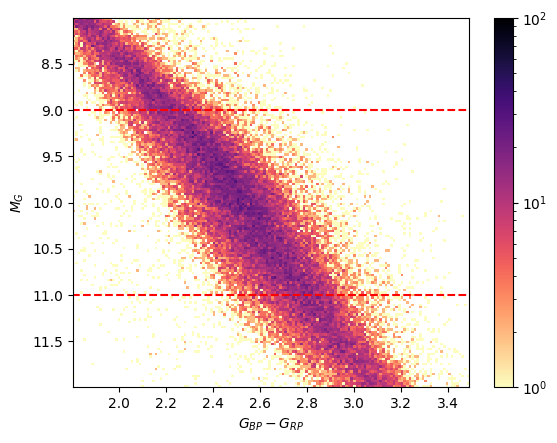

In [3]:
from matplotlib.colors import LogNorm
from matplotlib import colormaps 
fig, ax = plt.subplots()

cmap = colormaps['magma'].reversed()

_, _, _, h = ax.hist2d(data['bp_rp'], data['Abs_mag'], bins=150, cmap=cmap, norm=LogNorm(vmin=1e0, vmax=1e2))#, vmin=0, vmax=10)
ax.plot([color_cuts[0], color_cuts[1]], [9,9], 'r--')
ax.plot([color_cuts[0], color_cuts[1]], [11,11], 'r--')
ax.invert_yaxis()

ax.set(
    xlabel=r'$G_{BP} - G_{RP}$',
    ylabel=r'$M_G$'
)

fig.colorbar(h)
plt.show()

In [5]:
import read_mist_models as read_mist_models
m1 = read_mist_models.ISOCMD('data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd')

Reading in: data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd


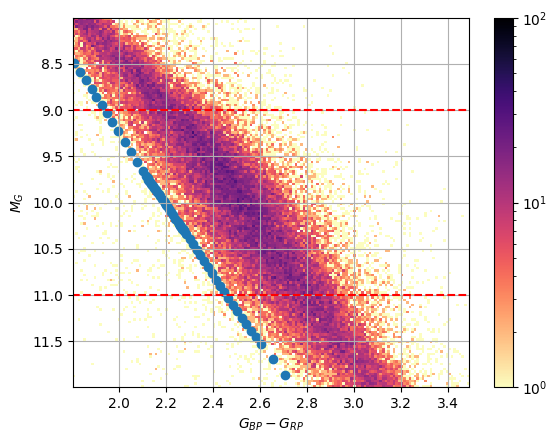

In [6]:
fig, ax = plt.subplots()

# cmap = colormaps['magma'].reversed()

_, _, _, h = ax.hist2d(data['bp_rp'], data['Abs_mag'], bins=150, cmap=cmap, norm=LogNorm(vmin=1e0, vmax=1e2))#, vmin=0, vmax=10)
ax.plot([color_cuts[0], color_cuts[1]], [9,9], 'r--')
ax.plot([color_cuts[0], color_cuts[1]], [11,11], 'r--')
ax.invert_yaxis()

ax.set(
    xlabel=r'$G_{BP} - G_{RP}$',
    ylabel=r'$M_G$'
)

fig.colorbar(h)


age_idx = m1.age_index(10)
cat = m1.isocmds[age_idx]

mag = cat['Gaia_G_DR2Rev']
color = cat['Gaia_BP_DR2Rev'] - cat['Gaia_RP_DR2Rev']

mask = (color>1.8) & (color<3.5) & (mag>8) & (mag<12)
mag = mag[mask]
color= color[mask]

ax.scatter(color, mag)
ax.invert_yaxis()
ax.invert_yaxis()
ax.grid()

In [7]:
iso = read_mist_models.ISOCMD('data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd')

Reading in: data/MIST_v1.2_vvcrit0.4_UBVRIplus/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_UBVRIplus.iso.cmd


In [72]:
ax2.get_xticks()

array([-2.50e+08,  0.00e+00,  2.50e+08,  5.00e+08,  7.50e+08,  1.00e+09,
        1.25e+09,  1.50e+09,  1.75e+09,  2.00e+09])

Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00032M.track.eep


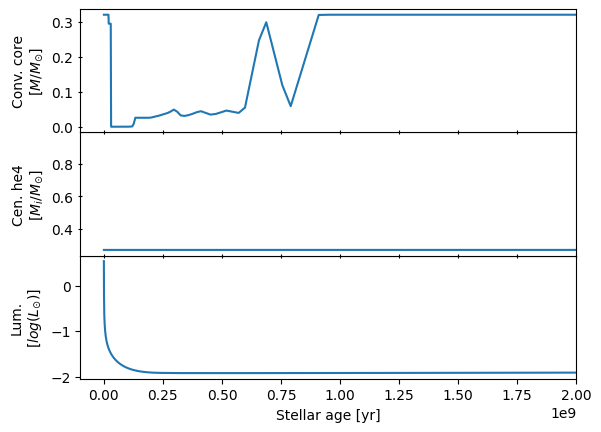

In [141]:
m032 = read_mist_models.EEP('data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00032M.track.eep').eeps

m032 = m032[m032['phase']<2]

fig = plt.figure()
ax3 = fig.add_subplot(3, 1, 3)
ax2 = fig.add_subplot(3, 1, 2)
ax = fig.add_subplot(3, 1, 1)

com_opt = {'xlim':(-1e8,2e9)}
ax.set(**com_opt, ylabel='Conv. core\n'+r'$[M/M_{\odot}]$')
ax2.set(**com_opt, ylabel='Cen. he4\n'+r'$[M_i/M_{\odot}]$')#, ylim=(0,0.3))
ax3.set(**com_opt, ylabel='Lum.\n'+r'$[log (L_{\odot})]$', xlabel=f'Stellar age [yr]')

ax.set_xticks(ax2.get_xticks()[1:], labels=[])
ax.tick_params(direction='inout')
ax2.set_xticks(ax3.get_xticks()[1:], labels=[])
ax2.tick_params(direction='inout')
fig.subplots_adjust(hspace=0.0)

ax.plot(m032['star_age'], m032['mass_conv_core'])
# ax.plot(m03['star_age'], m03['conv env top mass'])
ax2.plot(m032['star_age'], m032['center_he4'])
ax3.plot(m032['star_age'], m032['log_L'])

plt.show()

Reading in: data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00040M.track.eep


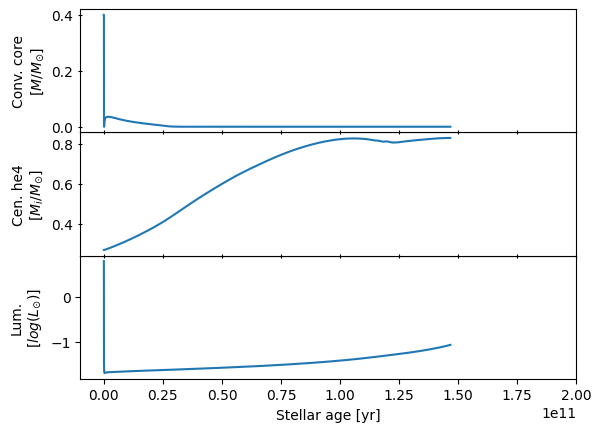

In [148]:
m03 = read_mist_models.EEP('data/MIST_v1.2_feh_p0.00_afe_p0.0_vvcrit0.4_EEPS/00040M.track.eep').eeps

m03 = m03[m03['phase']<2]

fig = plt.figure()
ax3 = fig.add_subplot(3, 1, 3)
ax2 = fig.add_subplot(3, 1, 2)
ax = fig.add_subplot(3, 1, 1)

com_opt = {'xlim':(-1e10,2e11)}
ax.set(**com_opt, ylabel='Conv. core\n'+r'$[M/M_{\odot}]$')
ax2.set(**com_opt, ylabel='Cen. he4\n'+r'$[M_i/M_{\odot}]$')
ax3.set(**com_opt, ylabel='Lum.\n'+r'$[log (L_{\odot})]$', xlabel=f'Stellar age [yr]')

ax.set_xticks(ax2.get_xticks()[1:], labels=[])
ax.tick_params(direction='inout')
ax2.set_xticks(ax3.get_xticks()[1:], labels=[])
ax2.tick_params(direction='inout')
fig.subplots_adjust(hspace=0.0)

ax.plot(m03['star_age'], m03['mass_conv_core'])
# ax.plot(m03['star_age'], m03['conv env top mass'])
ax2.plot(m03['star_age'], m03['center_he4'])
ax3.plot(m03['star_age'], m03['log_L'])

plt.show()